In [1]:
from pathlib import Path
import json
import configparser

# pip install slicerio

import slicerio.server

In [2]:
#%% Load OCT study information
folder_octexport_root = Path(r'G:\Projects\RemediReader\NAATOS_OCT_TEMP\OCTExport')
# this is also folder name
study_name = 'GHL_pyapp_20250320T1317'
folder_study = folder_octexport_root/study_name;
if not folder_study.exists:
    raise RuntimeError("Study not found")

# Load OCT study information And Check

In [3]:
# read the .json file we wrote on the OCT system
with open((folder_octexport_root/study_name)/'info.json',mode='r') as file:
    info = json.load(file);

# read the .ini settings file from Thorlabs OCT software
fileinipath = folder_study/(study_name+'_TS_DS_Parameters.ini')
if not fileinipath.exists():
    raise RuntimeError("INI file not found that should have been found")
config = configparser.ConfigParser();
config.read(fileinipath)
oct_conf = {k:dict(v) for k,v in config.items()};

# check that the expected files exist
for filoct in info['datanames']:
    filevtkpath = folder_study/((Path(filoct).stem)+'.vtk');
    if not filevtkpath.exists():
        raise RuntimeError("VTK file not found that should have been found")
    
    fileimagepath = folder_study/((Path(filoct).stem)+'_VideoImage.jpg');
    if not fileimagepath.exists():
        raise RuntimeError("Camera file not found that should have been found")

# Can we read the .vtk files with pyvista??

In [4]:
import pyvista as pv
vols = [];
for filoct in info['datanames']:
    filevtkpath = folder_study/((Path(filoct).stem)+'.vtk');
    print('Loading VTK volume',filevtkpath.name);
    vol = pv.read(filevtkpath);
    vols.append(vol);
    break;

Loading VTK volume GHL_pyapp_20250320T1317_0001_Mode3D.vtk


# Try

c:\Users\SimonGhionea\miniconda3\envs\OCT_naatos\Lib\site-packages\pyvista\jupyter\notebook.py:37: UserWarning: Failed to use notebook backend: 

cannot import name 'vtk' from 'trame.widgets' (c:\Users\SimonGhionea\miniconda3\envs\OCT_naatos\Lib\site-packages\trame\widgets\__init__.py)

Falling back to a static output.
  warnings.warn(


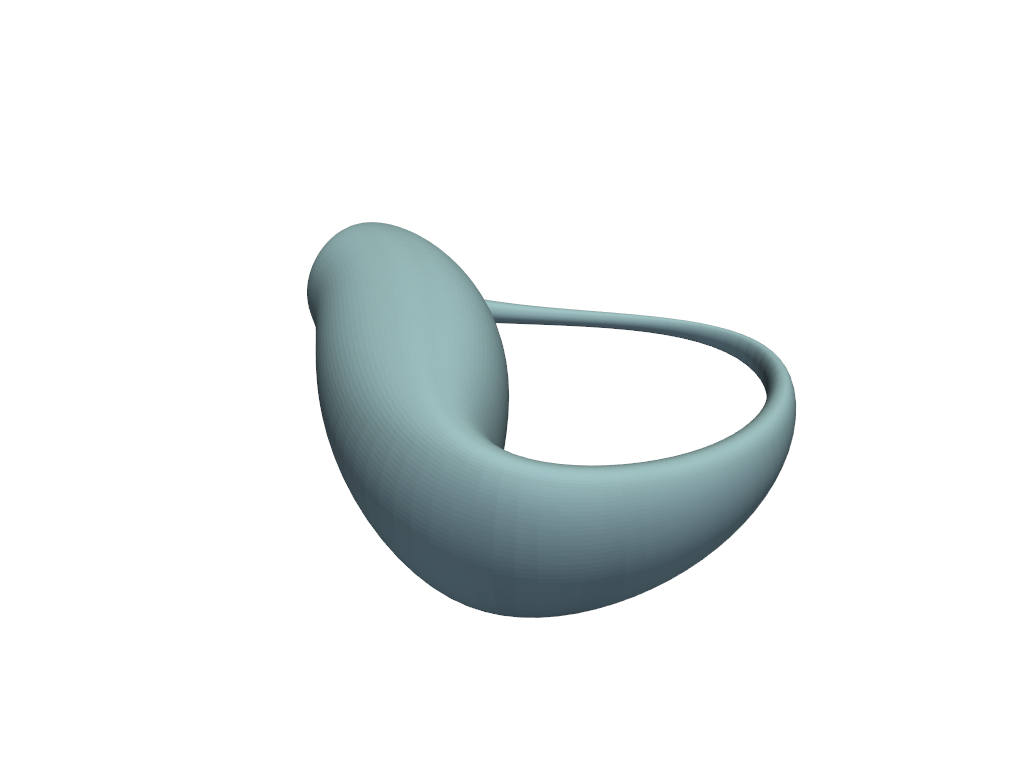

In [5]:
pl = pv.Plotter()
opacity = [0, 0, 0, 0.1, 0.3, 0.6, 1]
#pl.add_volume(vol, cmap="viridis", opacity=opacity)
pl.add_mesh(pv.ParametricKlein())
pl.show()